<style>
code, kbd, pre, samp {
    /*font-family:'consolas', Lucida Console, SimSun, Fira Code, Monaco !important;*/
    font-size: 11pt !important;
}

div.output_area pre {
    font-family: 'consolas', Lucida Console, SimSun, Fira Code, Monaco !important;
    font-size:  10pt !important;
}

div.output_area img, div.output_area svg {
    background-color: #FFFFFF !important;
}
</style>

Vintage analysis is a widely-used method for managing credit risk, it illustrate the behavior after an account was opened. Based on same origination period, it calculates charge-off ratio of a loan portfolio.

-----


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
!pip install lifelines
from lifelines import NelsonAalenFitter, CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test

# display settings
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 100)

# application_record.csv
application = pd.read_csv('/content/drive/MyDrive/project/application_record.csv')
print("Application record shape:", application.shape)
display(application.head())

# credit_record.csv
credit = pd.read_csv('/content/drive/MyDrive/project/credit_record.csv')
print("Credit record shape:", credit.shape)
display(credit.head())

Mounted at /content/drive
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 9.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=31c8df13dc4a585e832b3bdff490a377516c34ffc8e6c26ad21f5045319e0466
  Stored in directory: /root/.cache/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma
Application record shape: (438557, 18)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


Credit record shape: (1048575, 3)


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [ ]:
application

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.0


Explore ID matches: To understand the number and intersection of unique values of IDs in two tables and to determine which customers have a credit history.

In [ ]:
len(set(application['ID'])) # how many unique ID in application record?

438510

In [ ]:
len(set(credit['ID'])) # how many unique ID in credit record?

45985

Number of customers in common between the two tables, which is the customer we can use for modeling.

In [ ]:
len(set(application['ID']).intersection(set(credit['ID']))) # how many IDs do two tables share?

36457

# Vintage Analysis


In [ ]:
grouped = credit.groupby('ID')
# convert credit data to wide format which every ID is a row, columns are months, and the values are STATUS
pivot_tb = credit.pivot(index = 'ID', columns = 'MONTHS_BALANCE', values = 'STATUS')

# Get the start month and end month of each customer
pivot_tb['open_month'] = grouped['MONTHS_BALANCE'].min() # smallest value of MONTHS_BALANCE, is the month when loan was granted
pivot_tb['end_month'] = grouped['MONTHS_BALANCE'].max() # biggest value of MONTHS_BALANCE, might be observe over or canceling account
pivot_tb['ID'] = pivot_tb.index

# keep the desired columns
pivot_tb = pivot_tb[['ID', 'open_month', 'end_month']]

# calculate observe window
pivot_tb['window'] = pivot_tb['end_month'] - pivot_tb['open_month']

# reset index
pivot_tb.reset_index(drop = True, inplace = True)

# merge back into the credit table
credit = pd.merge(credit, pivot_tb, on = 'ID', how = 'left')

In [ ]:
credit0 = credit.copy()
# delete users whose observe window less than 20
credit = credit[credit['window'] > 20]

# construct the seriously overdue label status
credit['status'] = np.where((credit['STATUS'] == '2') | (credit['STATUS'] == '3' )| (credit['STATUS'] == '4' )| (credit['STATUS'] == '5'), 1, 0) # analyze > 60 days past due
credit['status'] = credit['status'].astype(np.int8) # 1: overdue 0: not

# calculate month on book: how many months after opening account
credit['month_on_book'] = credit['MONTHS_BALANCE'] - credit['open_month']
# Make sure the data is in chronological order
credit.sort_values(by = ['ID','month_on_book'], inplace = True)
credit.head()

,ID,MONTHS_BALANCE,STATUS,open_month,end_month,window,status,month_on_book
44,5001713,-21,X,-21,0,21,0,0
43,5001713,-20,X,-21,0,21,0,1
42,5001713,-19,X,-21,0,21,0,2
41,5001713,-18,X,-21,0,21,0,3
40,5001713,-17,X,-21,0,21,0,4


In [ ]:
# denominator (number of users per month)
denominator = pivot_tb.groupby(['open_month']).agg({'ID': ['count']}) # count how many users in every month the account was opened
denominator.reset_index(inplace = True)
denominator.columns = ['open_month','sta_sum'] # sta_sum indicates the number of card users per month
# denominator is then used to calculate the "cumulative default ratio"

# ventage table
# Build the infrastructure: a combination of each open_month and each month_on_book
vintage = credit.groupby(['open_month','month_on_book']).agg({'ID': ['count']})
vintage.reset_index(inplace = True)
vintage.columns = ['open_month','month_on_book','sta_sum']

# Added column for cumulative default customers
vintage['due_count'] = np.nan

# Keep only the structure fields and the columns we want to compute
vintage = vintage[['open_month','month_on_book','due_count']]

# Total number of customers added per open_month (denominator)
vintage = pd.merge(vintage, denominator, on = ['open_month'], how = 'left') # join sta_sum colun to vintage table
vintage

,open_month,month_on_book,due_count,sta_sum
0,-60,0,NaN,415
1,-60,1,NaN,415
2,-60,2,NaN,415
3,-60,3,NaN,415
4,-60,4,NaN,415
...,...,...,...,...
1655,-21,17,NaN,858
1656,-21,18,NaN,858
1657,-21,19,NaN,858
1658,-21,20,NaN,858


In [ ]:
for j in range(-60,1): # outer loop: month in which account was opened
    ls = [] # Save a list of historical bad customer ids
    for i in range(0,61): # inner loop time after the credit card was granted
        due = list(credit[(credit['status'] == 1) & (credit['month_on_book'] == i) & (credit['open_month'] == j)]['ID']) # get ID which satisfy the condition
        ls.extend(due) # As time goes, add bad customers
        vintage.loc[(vintage['month_on_book'] == i) & (vintage['open_month'] == j), 'due_count'] = len(set(ls)) # calculate non-duplicate ID numbers using set()

In [ ]:
# Calculate the proportion of bad customers
vintage['sta_rate']  = vintage['due_count'] / vintage['sta_sum']
vintage

,open_month,month_on_book,due_count,sta_sum,sta_rate
0,-60,0,0.0,415,0.000000
1,-60,1,0.0,415,0.000000
2,-60,2,0.0,415,0.000000
3,-60,3,0.0,415,0.000000
4,-60,4,0.0,415,0.000000
...,...,...,...,...,...
1655,-21,17,15.0,858,0.017483
1656,-21,18,15.0,858,0.017483
1657,-21,19,15.0,858,0.017483
1658,-21,20,15.0,858,0.017483


Using `pivot` to convert long data to wide data:

In [ ]:
# Vintage wide table
vintage_wide = vintage.pivot(
    index = 'open_month',
    columns = 'month_on_book',
    values = 'sta_rate')
vintage_wide

month_on_book,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60
open_month,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
-60,0.00000,0.000000,0.000000,0.000000,0.000000,0.002410,0.002410,0.007229,0.007229,0.009639,0.009639,0.012048,0.014458,0.016867,0.016867,0.016867,0.016867,0.016867,0.016867,0.016867,0.016867,0.019277,0.019277,0.019277,0.019277,0.021687,0.021687,0.021687,0.021687,0.024096,0.026506,0.026506,0.026506,0.026506,0.026506,0.026506,0.026506,0.026506,0.026506,0.026506,0.026506,0.026506,0.026506,0.026506,0.026506,0.026506,0.026506,0.026506,0.026506,0.026506,0.028916,0.028916,0.028916,0.028916,0.028916,0.028916,0.028916,0.028916,0.031325,0.031325,0.031325
-59,0.00000,0.000000,0.000000,0.004926,0.004926,0.004926,0.007389,0.007389,0.007389,0.012315,0.012315,0.019704,0.019704,0.019704,0.019704,0.019704,0.019704,0.019704,0.022167,0.024631,0.024631,0.027094,0.027094,0.027094,0.027094,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.029557,0.032020,0.032020,0.032020,0.032020,0.032020,0.032020,NaN
-58,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004545,0.006818,0.006818,0.011364,0.013636,0.013636,0.013636,0.013636,0.013636,0.013636,0.015909,0.018182,0.018182,0.018182,0.022727,0.022727,0.022727,0.022727,0.022727,0.022727,0.022727,0.022727,0.022727,0.022727,0.022727,0.022727,0.022727,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,NaN,NaN
-57,0.00000,0.000000,0.000000,0.000000,0.002500,0.002500,0.002500,0.007500,0.007500,0.007500,0.007500,0.007500,0.010000,0.017500,0.017500,0.017500,0.017500,0.017500,0.017500,0.017500,0.017500,0.017500,0.017500,0.017500,0.020000,0.020000,0.020000,0.020000,0.020000,0.020000,0.020000,0.020000,0.020000,0.020000,0.020000,0.022500,0.022500,0.022500,0.022500,0.022500,0.022500,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,NaN,NaN,NaN
-56,0.00000,0.000000,0.004255,0.004255,0.008511,0.010638,0.010638,0.017021,0.017021,0.021277,0.021277,0.025532,0.029787,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.034043,0.036170,0.036170,0.036170,0.036170,0.038298,0.038298,NaN,NaN,NaN,NaN
-55,0.00000,0.000000,0.002058,0.006173,0.012346,0.016461,0.022634,0.022634,0.022634,0.024691,0.024691,0.024691,0.026749,0.032922,0.034979,0.037037,0.039095,0.039095,0.039095,0.039095,0.039095,0.039095,0.039095,0.039095,0.039095,0.039095,0.041152,0.041152,0.041152,0.041152,0.041152,0.041152,0.041152,0.043210,0.043210,0.043210,0.043210,0.043210,0.043210,0.045267,0.045267,0.045267,0.045267,0.045267,0.045267,0.045267,0.045267,0.045267,0.045267,0.045267,0.045267,0.045267,0.045267,0.045267,0.045267,0.045267,NaN,NaN,NaN,NaN,NaN
-54,0.00000,0.000000,0.000000,0.002137,0.004274,0.004274,0.006410,0.012821,0.012821,0.017094,0.019231,0.019231,0.023504,0.027778,0.027778,0.029915,0.029915,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,0.032051,NaN,Na

This is a standard vingtage analysis table. The rows represent months of opening accounts, columns represent months after openning acounts, and values are accumlate past-due rate. As open-month closes to 0, the observe window shortens, thus the bottom half triangular field is filled by nan.

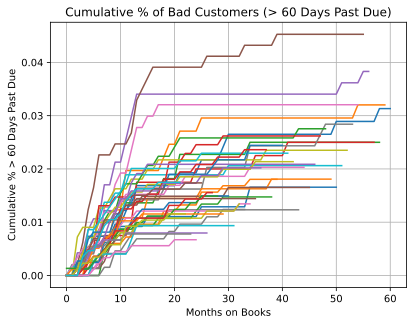

In [ ]:
# plot vintage line chart (Visualize the default evolution of customers who open cards at different points in time)
plt.rcParams['figure.facecolor'] = 'white'


vintage0 = vintage_wide.replace(0,np.nan)
lst = [i for i in range(0,61)]
vintage_wide[lst].T.plot(legend = False, grid = True, title = 'Cumulative % of Bad Customers (> 60 Days Past Due)')

plt.xlabel('Months on Books')
plt.ylabel('Cumulative % > 60 Days Past Due')
plt.show()

Each line represents a different "card month" of customers, and the slope and final level of the curve reflect changes in the "credit quality" of this group of customers. If the curve of a customer who opens a card in a month climbs particularly fast, that group of people "bad fast." If the curve is smooth, then the risk is well controlled.

# Observe Window Analysis

Because of two reasons, account cancellation and observe over, our observe on accounts will be truncated. Observe window is a significant parameter to be considered. If observe window is too short, users' behavior will not fully show off, which will bring unnecessary noise to our data.

In order to observe how many accounts increase as observe window extend, we plot this.

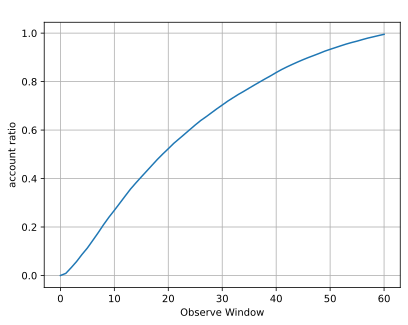

In [ ]:
# X-axis: Observation window length (0-60 months)
# Y-axis: The percentage of customers under observation for less than that month (what is the percentage of accounts under observation for less than X months)
lst = []
for i in range(0,61):
    ratio = len(pivot_tb[pivot_tb['window'] < i]) / len(set(pivot_tb['ID']))
    lst.append(ratio)

pd.Series(lst).plot(legend = False, grid = True, title = ' ')
plt.xlabel('Observe Window')
plt.ylabel('account ratio')
plt.show()

This chart reflects the proportion of lost customers per observation window length - for customers whose observation window is too short, the data may be incomplete and the default cannot be observed. We could see that a 60 months observe window covers all appliers, while 20 months window contains about 52% records.

In [ ]:
def calculate_observe(credit, command):
    '''calculate observe window for given overdue condition'''
    id_sum = len(set(pivot_tb['ID'])) #total customers
    credit['status'] = 0
    exec(command) #Execute the incoming filter
    credit['month_on_book'] = credit['MONTHS_BALANCE'] - credit['open_month']

    # Count each bad customer's first default month
    minagg = credit[credit['status'] == 1].groupby('ID')['month_on_book'].min().reset_index()

    obslst = pd.DataFrame({'month_on_book':range(0,61), 'rate': None})
    lst = []
    for i in range(0,61):
        due = list(minagg[minagg['month_on_book']  == i]['ID'])
        lst.extend(due)
        obslst.loc[obslst['month_on_book'] == i, 'rate'] = len(set(lst)) / id_sum
    return obslst['rate']

#command is the definition of various overdue levels, and morethanx is the calculation of the cumulative bad debt ratio under different conditions
command = "credit.loc[(credit['STATUS'] == '0') | (credit['STATUS'] == '1') | (credit['STATUS'] == '2') | (credit['STATUS'] == '3' )| (credit['STATUS'] == '4' )| (credit['STATUS'] == '5'), 'status'] = 1"
morethan1 = calculate_observe(credit, command)
command = "credit.loc[(credit['STATUS'] == '1') | (credit['STATUS'] == '2') | (credit['STATUS'] == '3' )| (credit['STATUS'] == '4' )| (credit['STATUS'] == '5'), 'status'] = 1"
morethan30 = calculate_observe(credit, command)
command = "credit.loc[(credit['STATUS'] == '2') | (credit['STATUS'] == '3' )| (credit['STATUS'] == '4' )| (credit['STATUS'] == '5'), 'status'] = 1"
morethan60 = calculate_observe(credit, command)
command = "credit.loc[(credit['STATUS'] == '3' )| (credit['STATUS'] == '4' )| (credit['STATUS'] == '5'), 'status'] = 1"
morethan90 = calculate_observe(credit, command)
command = "credit.loc[(credit['STATUS'] == '4' )| (credit['STATUS'] == '5'), 'status'] = 1"
morethan120 = calculate_observe(credit, command)
command = "credit.loc[(credit['STATUS'] == '5'), 'status'] = 1"
morethan150 = calculate_observe(credit, command)

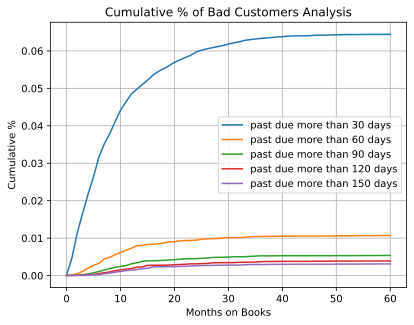

In [ ]:
obslst = pd.DataFrame({'past due more than 30 days': morethan30,
                       'past due more than 60 days': morethan60,
                       'past due more than 90 days': morethan90,
                       'past due more than 120 days': morethan120,
                       'past due more than 150 days': morethan150
                        })

obslst.plot(grid = True, title = 'Cumulative % of Bad Customers Analysis')
plt.xlabel('Months on Books')
plt.ylabel('Cumulative %')
plt.show()

This plot could be seen as a average (across open-month) version of vintage plot.
For longer past due date, it needs longer observe window. For example, more than 150 days past due needs at least 5 months until first *bad customer* appears. For most situation, a 20-months observe window could cover most *bad customer*. However, For 30 days past due, we could see that after 30 months on books, there still are new *bad customer* join in the list. So a 20 MOB observe window will be appropriate. Those who exists shorter than the observe window should be excluded from our analysis, thus you could see I deleted users whose observe window less than 20 on last section (the window could be changed).

# Overall Past-due Ratio

Calculating overall past-due rate. Respectively, we analyze 1 day past due, 20 days past due, 60 days past due, 90 days past due, 120 days past due, 150 days past due. This analysis could help us to define who are *bad customers*. We could see that almost 87% users have past due more than 1 day, which is too common, thus it's inappropriate to be a standard. What about 150 days overdue? Only 0.4% of accounts appear to past due that long. If we use that, we will left many *bad customers* in our scrutiny. A table like that will help you to determine what  will be the most suitable standard of *bad customers*.

In [ ]:
def calculate_rate(pivot_tb, command):
    '''calculate bad customer rate
    '''
    credit0['status'] = None
    exec(command) # excuate input code
    sumagg = credit0.groupby('ID')['status'].agg(sum)

    # Merge back into the customer table
    pivot_tb = pd.merge(pivot_tb, sumagg, on = 'ID', how = 'left')
    pivot_tb.loc[pivot_tb['status'] > 1, 'status'] = 1

    rate = pivot_tb['status'].sum() / len(pivot_tb)
    return round(rate, 5)

command = "credit0.loc[(credit0['STATUS'] == '0') | (credit0['STATUS'] == '1') | (credit0['STATUS'] == '2') | (credit0['STATUS'] == '3' )| (credit0['STATUS'] == '4' )| (credit0['STATUS'] == '5'), 'status'] = 1"
morethan1 = calculate_rate(pivot_tb, command)
command = "credit0.loc[(credit0['STATUS'] == '1') | (credit0['STATUS'] == '2') | (credit0['STATUS'] == '3' )| (credit0['STATUS'] == '4' )| (credit0['STATUS'] == '5'), 'status'] = 1"
morethan30 = calculate_rate(pivot_tb, command)
command = "credit0.loc[(credit0['STATUS'] == '2') | (credit0['STATUS'] == '3' )| (credit0['STATUS'] == '4' )| (credit0['STATUS'] == '5'), 'status'] = 1"
morethan60 = calculate_rate(pivot_tb, command)
command = "credit0.loc[(credit0['STATUS'] == '3' )| (credit0['STATUS'] == '4' )| (credit0['STATUS'] == '5'), 'status'] = 1"
morethan90 = calculate_rate(pivot_tb, command)
command = "credit0.loc[(credit0['STATUS'] == '4' )| (credit0['STATUS'] == '5'), 'status'] = 1"
morethan120 = calculate_rate(pivot_tb, command)
command = "credit0.loc[(credit0['STATUS'] == '5'), 'status'] = 1"
morethan150 = calculate_rate(pivot_tb, command)

summary_dt = pd.DataFrame({'situation':['past due more than 1 day',
                               'past due more than 30 days',
                               'past due more than 60 days',
                               'past due more than 90 days',
                               'past due more than 120 days',
                               'past due more than 150 days'],
                      'bad customer ratio':[morethan1,
                               morethan30,
                               morethan60,
                               morethan90,
                               morethan120,
                               morethan150,
                      ]})
summary_dt

,situation,bad customer ratio
0,past due more than 1 day,0.87054
1,past due more than 30 days,0.11634
2,past due more than 60 days,0.01450
3,past due more than 90 days,0.00720
4,past due more than 120 days,0.00528
5,past due more than 150 days,0.00424


# Kaplan-Meier survival Analysis (KM curve)

Kaplan-Meier analyzed the percentage of customers who are "alive" each month, that is, those who are not bad over time.

In [ ]:
# Mark whether each customer is ultimately in default (truncate = 1 indicates that the person is finally bad)
credit['truncate'] = credit.groupby('ID')['status'].transform('max')

# No bad customer: the longest observation period
not_trunc = credit[credit['truncate'] == 0]
dt1 = not_trunc.groupby('ID').agg({
    'month_on_book': 'max',
    'truncate': 'max'
}).reset_index()

# Bad customer: First bad month of age
trunc = credit[credit['truncate'] == 1]
dt2 = trunc[trunc['status'] == 1].groupby('ID').agg({
    'month_on_book': 'min',
    'truncate': 'max'
}).reset_index()

# Merge two types of customers
dt = pd.concat([dt1, dt2], ignore_index=True)
dt.columns = ['ID', 'month_on_book', 'truncate']

dt.head()

,ID,month_on_book,truncate
0,5001713,21,0
1,5001715,59,0
2,5001717,21,0
3,5001718,38,0
4,5001719,42,0


month_on_book is the longest it has lived (if it's broken it's the earliest month)

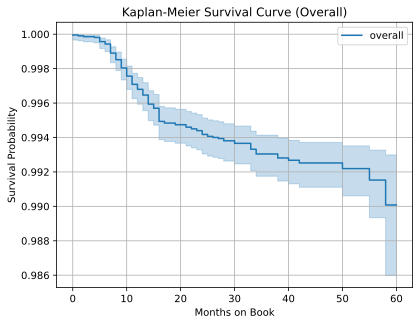

In [ ]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

# fit the data
kmf.fit(
    durations=dt['month_on_book'],        # Survival time
    event_observed=dt['truncate'],        # Whether a "death" occurred (default)
    label='overall'
)

# plot
kmf.plot()
plt.title("Kaplan-Meier Survival Curve (Overall)")
plt.xlabel("Months on Book")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()

The curve starts at 1 (100% of customers are "healthy"); Over time, the curve declines (there are customer defaults); The earlier the decline is faster, indicating that the early bad customers are more; Stabilizing indicates that bad customers are gradually "released" and the risk is stabilizing.
Next, the grouped KM curve (customer profile analysis) is conducted to explore the impact of different gender/marriage/education/property ownership on default risk.


In [ ]:
# Merge basic customer information and prepare grouping variables: Extract several key variabless from the application table and merge them into dt
# extract key variables
application_sub = application[[
    'ID', 'CODE_GENDER', 'FLAG_OWN_CAR',
    'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE'
]]

# merge into dt
dt = pd.merge(dt, application_sub, on='ID', how='left')

# handle missing value
dt.fillna('unknown', inplace=True)

dt.head()


,ID,month_on_book,truncate,CODE_GENDER,FLAG_OWN_CAR,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE
0,5001713,21,0,unknown,unknown,unknown,unknown,unknown
1,5001715,59,0,unknown,unknown,unknown,unknown,unknown
2,5001717,21,0,unknown,unknown,unknown,unknown,unknown
3,5001718,38,0,unknown,unknown,unknown,unknown,unknown
4,5001719,42,0,unknown,unknown,unknown,unknown,unknown


In [ ]:
from lifelines import KaplanMeierFitter
import numpy as np

def plot_km(dt, timevar, eventvar, groupvar, title):
    '''Plot the group KM curve'''
    plt.figure(figsize=(8, 6))
    kmf = KaplanMeierFitter()
    t = np.linspace(0, 60, 61)

    for group in dt[groupvar].unique():
        mask = dt[groupvar] == group
        kmf.fit(dt[mask][timevar], event_observed=dt[mask][eventvar], timeline=t, label=str(group))
        kmf.plot(ci_show=False)

    plt.title(f'KM Curve by {groupvar} - {title}')
    plt.xlabel('Months on Book')
    plt.ylabel('Survival Probability')
    plt.grid(True)
    plt.legend(title=groupvar)
    plt.show()


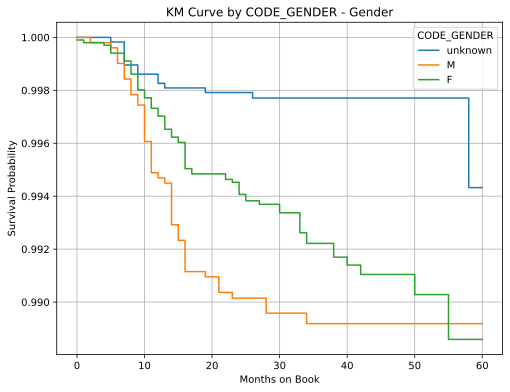

In [ ]:
plot_km(
    dt=dt,
    timevar='month_on_book',
    eventvar='truncate',
    groupvar='CODE_GENDER',
    title='Gender'
)

Men's (M) curve falls faster, survival rates are lower, and default rates are higher. Female (F) is more "stable" on the whole, and the default probability is relatively low, indicating that gender is indeed one of the important variables affecting the default risk.

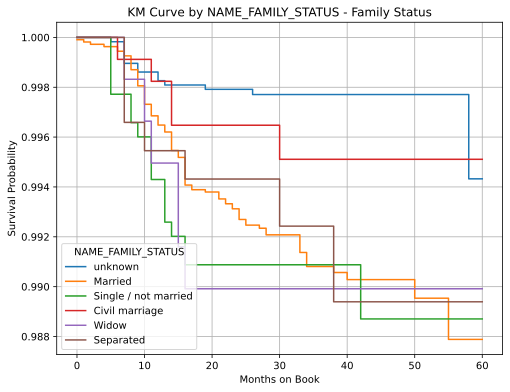

In [ ]:
plot_km(dt, 'month_on_book', 'truncate', 'NAME_FAMILY_STATUS', 'Family Status')

There is a strong correlation between marital status and risk. The credit stability of single/divorced people is significantly weaker than that of other groups. De facto marriages are even less risky than formal marriages, which can be a valuable feature in real-world modeling

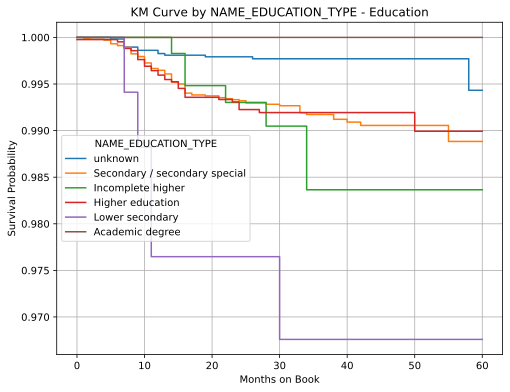

In [ ]:
plot_km(dt, 'month_on_book', 'truncate', 'NAME_EDUCATION_TYPE', 'Education')

Education correlates with credit stability: the higher the education level, the lower the overall default risk. This feature is one of the most valuable variables for future scorecards.

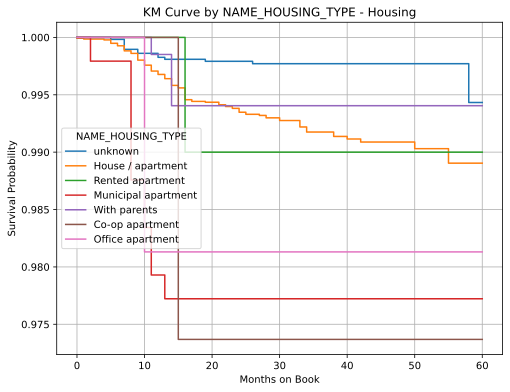

In [ ]:
plot_km(dt, 'month_on_book', 'truncate', 'NAME_HOUSING_TYPE', 'Housing')

Residential stability (owned/shared/rented) is closely related to default risk; "Public housing/unit housing/living with parents" these non-autonomous living groups have higher credit risks; Although House/apartment accounts for the largest proportion, it still cannot be generalized as "low risk".

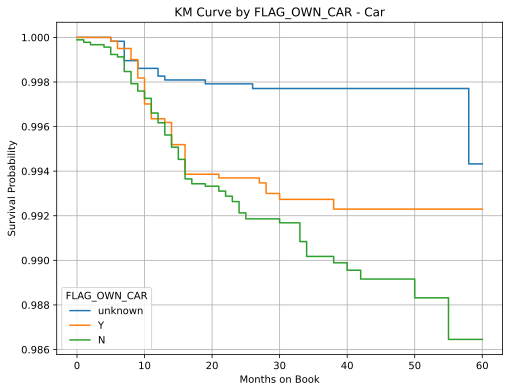

In [ ]:
plot_km(dt, 'month_on_book', 'truncate', 'FLAG_OWN_CAR', 'Car')

Owning a car represents a certain asset capacity, so credit risk is lower; Non-car customers have higher credit default rate, which can be used as a risk variable. This once again validates the classic credit rule of thumb that asset variables are negatively correlated with default risk.

We define a customer as "bad" if they have ever had a credit STATUS of 2 or higher (i.e., 60+ days past due).
This threshold is chosen because:It aligns with common credit risk standards. Vintage and survival analysis show most serious delinquencies occur within 20 months. It balances early risk detection with label reliability.

# Label

In [ ]:
# Make sure STATUS is a string type
credit0['STATUS'] = credit0['STATUS'].astype(str)

# Construct tag: STATUS ≥ 2 (Severely overdue)
credit0['label'] = credit0['STATUS'].isin(['2', '3', '4', '5']).astype(int)

# Aggregation to the customer level: As long as it appears once, it is recorded as a bad customer
label_df = credit0.groupby('ID')['label'].max().reset_index()

In [ ]:
# Keep only customers with a credit history in the application
df_model = pd.merge(application, label_df, on='ID', how='inner')

# view the results
print("Shape of modeling dataset:", df_model.shape)
df_model[['ID', 'label']].head()

Shape of modeling dataset: (36457, 19)


,ID,label
0,5008804,0
1,5008805,0
2,5008806,0
3,5008808,0
4,5008809,0


In [ ]:
df_model['label'].value_counts(normalize=True).round(3)

,proportion
label,
0,0.983
1,0.017


serious imbalance in the data

1. We only keep customers who have a credit history. 430,000 + users in the original application; But only about 46,000 people have transactions in credit_record.csv; And only 36,000+ people observed window ≥ 20 (we deleted people with window < 20);
2. Among these people, the customers who can be successfully labeled are further screened. That is to say, only the customer who can determine whether he has STATUS ≥ 2 is retained; The resulting 36,457 lines are people who have both characteristic data and a credit history and can be tagged.